## Import libraries

In [2]:
# import keras
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import tensorflow as tf
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

tf.keras.utils.set_random_seed(42)

## Correlation Analysis

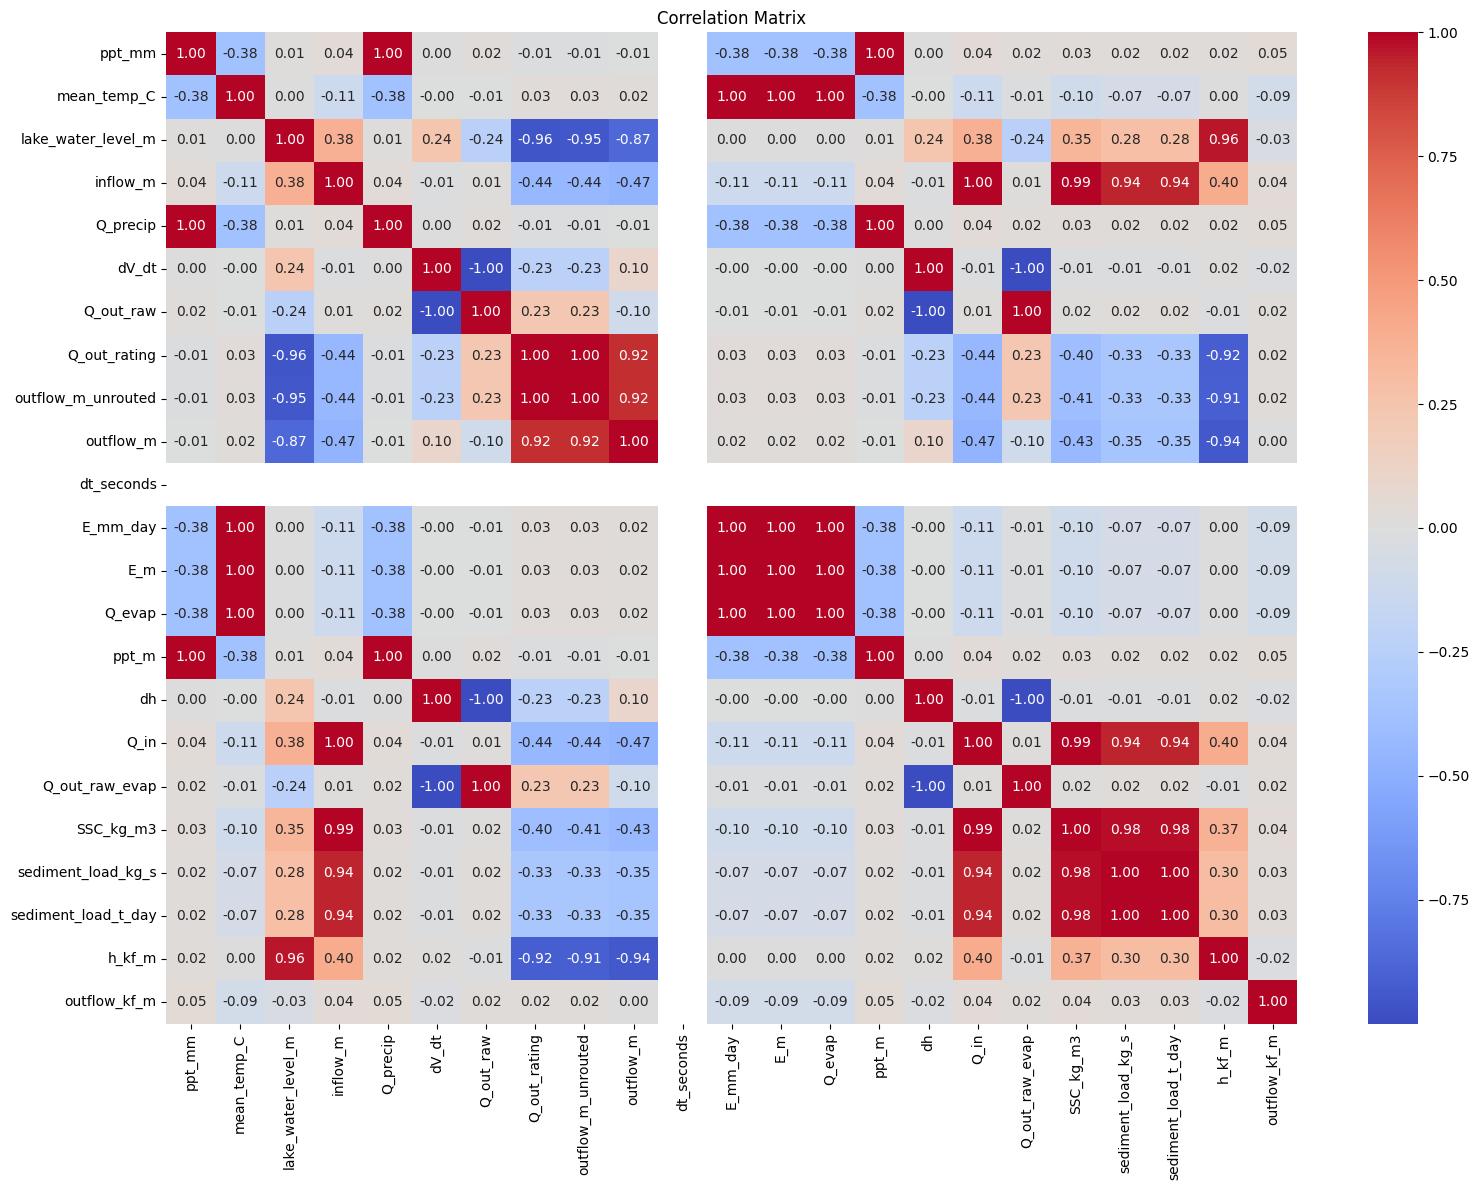

In [3]:
data = pd.read_csv("Lake_Albert_Hydrology_dataset.csv", parse_dates=["Date"], index_col=["Date"])
# Correlation matrix
corr_matrix = data.corr(method='pearson')
# heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="coolwarm", center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Drop some outputs and insignificant variables

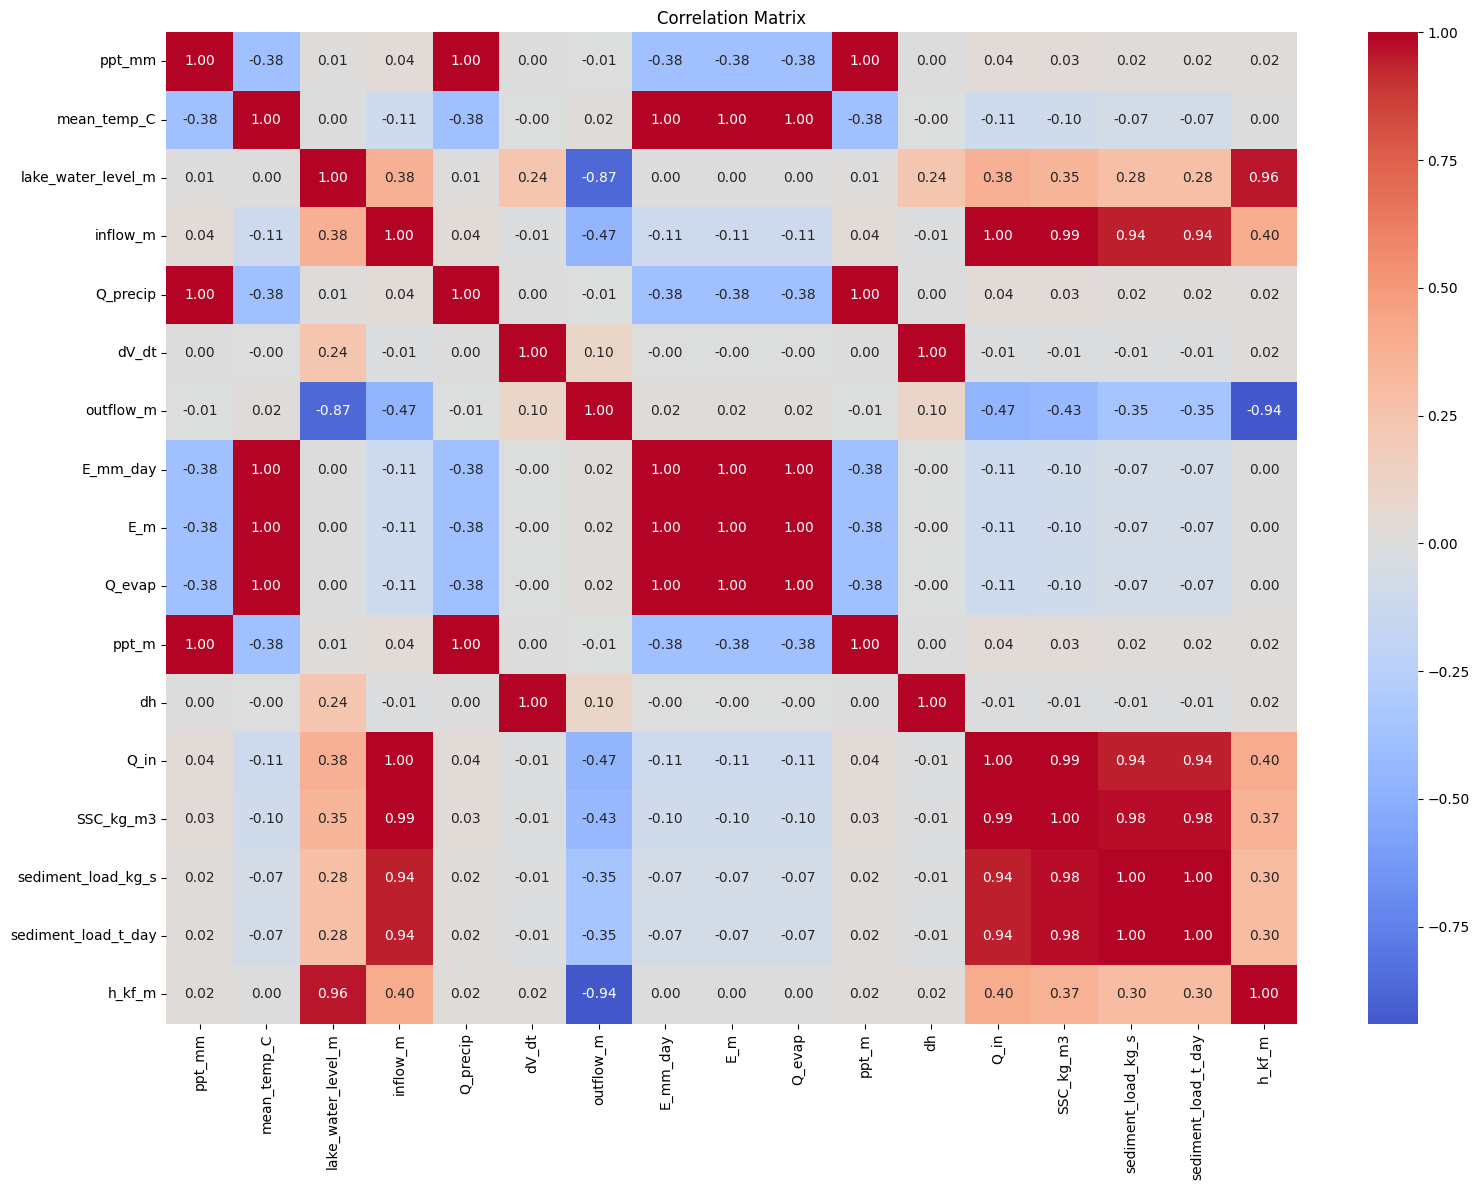

In [4]:
remove_columns = ["dt_seconds", "Q_out_raw", "Q_out_rating", "outflow_m_unrouted", "Q_out_raw_evap", "outflow_kf_m", 
    # "ppt_mm", "E_mm_day", "h_kf_m", "Q_evap", "inflow_m", "sediment_load_kg_s", 
    #  "E_m", "ppt_m","SSC_kg_m3", "dh", "sediment_load_t_day"
    ]
target = "outflow_m"
data_drop = data.drop(remove_columns, axis=1)
# Correlation matrix
corr_matrix_new = data_drop.corr(method='pearson')
# heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix_new, annot=True, fmt=".2f",
    cmap="coolwarm", center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

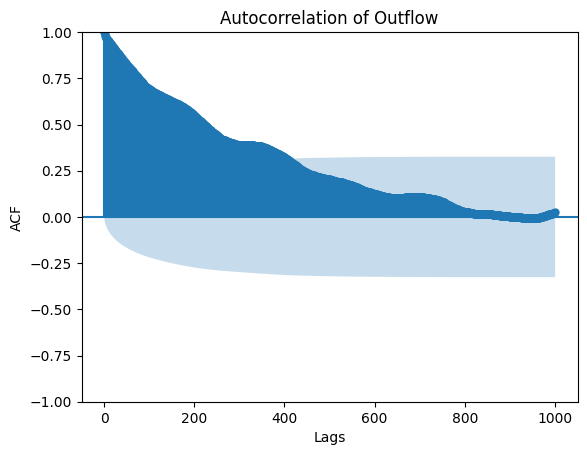

In [5]:
# Autocorrelation
plt.figure(figsize=(10,6))
plot_acf(
    data_drop[target],
    lags=1000,          # Check until 1000 days
    alpha=0.05        # confidence interval 95%
)
plt.title("Autocorrelation of Outflow")
plt.xlabel('Lags')
plt.ylabel('ACF')
plt.show()

## Prepare data for XGBoost

In [6]:
df = data_drop.copy()
forecast_horizon, target_cols = 7, []
target_lags = [1, 2, 3, 7, 14, 30]
feature_lags = {
    "ppt_mm": [1, 3, 7],
    "Q_in": [1, 3, 7],
    "inflow_m": [1, 3, 7],
    "lake_water_level_m": [1, 3, 7],
}
data_drop['doy'] = data_drop.index.dayofyear
data_drop["sin_doy"] = np.sin(2 * np.pi * data_drop["doy"] / 365)
data_drop["cos_doy"] = np.cos(2 * np.pi * data_drop["doy"] / 365)
for col, lags in feature_lags.items():
    for lag in lags:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)
for h in range(1, forecast_horizon + 1):
    col_name = f"target_t{h}"
    df[col_name] = df[target].shift(-h)
    target_cols.append(col_name)
df = df.dropna()
drop_cols = [target] + target_cols
X, y = df.drop(columns=drop_cols), df[target_cols]

In [7]:
train_size = int(len(df) * 0.7)
X_train_XGBoost = X.iloc[:train_size]
X_test_XGBoost = X.iloc[train_size:]
y_train_XGBoost = y.iloc[:train_size]
y_test_XGBoost = y.iloc[train_size:]

## Train XGBoost model

In [8]:
base_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
)
model = MultiOutputRegressor(base_model)
model.fit(X_train_XGBoost, y_train_XGBoost)
y_pred_XGBoost = model.predict(X_test_XGBoost)
y_pred_XGBoost = pd.DataFrame(
    y_pred_XGBoost, columns=target_cols,
    index=y_test_XGBoost.index
)

## XGBoost performance

In [9]:
metrics = []
print("\n===== MULTI-HORIZON PERFORMANCE XGBRegressor =====")
for h in range(len(y_pred_XGBoost.columns)):
    true_vals = y_test_XGBoost.iloc[:, h].values
    pred_vals = y_pred_XGBoost.iloc[:, h].values
    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    mae = mean_absolute_error(true_vals, pred_vals)
    r2 = r2_score(true_vals,pred_vals)
    nse = 1 - (
        np.sum((true_vals - pred_vals) ** 2)
        / np.sum(
            (true_vals - np.mean(true_vals)) ** 2
        )
    )
    metrics.append([h + 1,rmse,mae,r2,nse])
# dataframe metrics
metrics_df = pd.DataFrame(
    metrics,
    columns=[
        "Horizon","RMSE","MAE","R2","NSE"
    ]
)
print(metrics_df)


===== MULTI-HORIZON PERFORMANCE XGBRegressor =====
   Horizon       RMSE        MAE        R2       NSE
0        1   3.295136   1.982275  0.999019  0.999019
1        2  15.555713   6.509479  0.978129  0.978129
2        3  19.707738   8.593158  0.964877  0.964877
3        4  22.781258  10.519796  0.953040  0.953040
4        5  25.113236  12.026832  0.942901  0.942901
5        6  26.376247  13.356647  0.936974  0.936974
6        7  28.081869  14.600913  0.928518  0.928518


## Forecasted plots (1, 2, 3, 4, 5, 6, 7 days head)

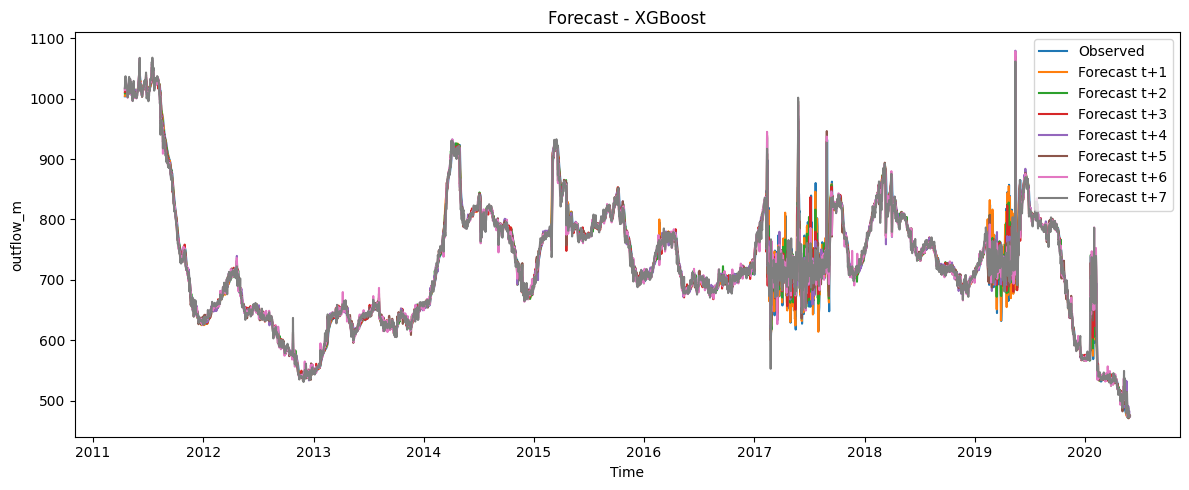

In [10]:
# fig = go.Figure()
# fig.add_trace(
#     go.Scatter(
#         x=y_test_XGBoost.index, y=data_drop.loc[data_drop.index.isin(y_test_XGBoost.index)][target].values,
#         mode="lines", name="Observed"
#     )
# )
# for h in range(0, forecast_horizon):
#     fig.add_trace(
#         go.Scatter(
#             x=y_test_XGBoost.index, y=y_pred_XGBoost.iloc[:, h],
#             mode="lines", name=f"Forecast t+{h+1}"
#         )
#     )
# fig.update_layout(
#     template="plotly_white",
#     title=f"Forecast - XGBoost",
#     xaxis_title="Time", yaxis_title=target,
#     width=1200, height=500, showlegend=True,
# )
# fig.show()

plt.figure(figsize=(12, 5))
# Observed
plt.plot(
    y_test_XGBoost.index,
    data_drop.loc[data_drop.index.isin(y_test_XGBoost.index)][target].values,
    label="Observed"
)
# Forecast horizons
for h in range(forecast_horizon):
    plt.plot(
        y_test_XGBoost.index, y_pred_XGBoost.iloc[:, h], label=f"Forecast t+{h+1}"
    )
plt.title("Forecast - XGBoost")
plt.xlabel("Time")
plt.ylabel(target)
plt.legend()
plt.tight_layout()
plt.show()

## Feature importance

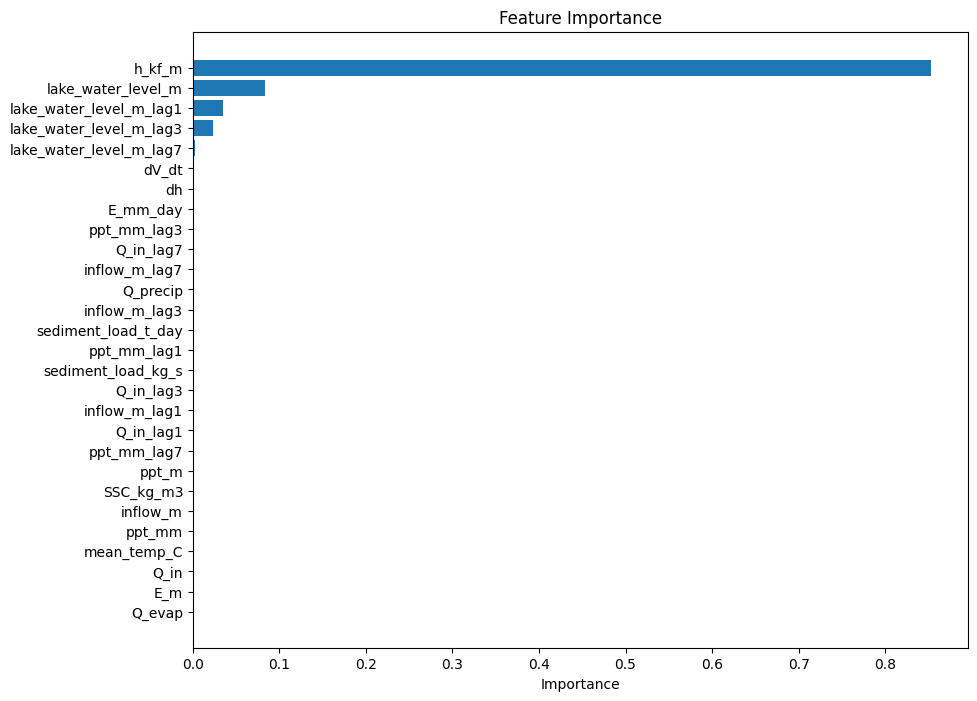

In [11]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": (
        model.estimators_[0]
        .feature_importances_
    )
})

importance = importance.sort_values(
    by="importance", ascending=False
)

plt.figure(figsize=(10,8))
top_n = 200
plt.barh(
    importance["feature"].head(top_n)[::-1],
    importance["importance"].head(top_n)[::-1]
)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

## Prepare data for LSTM model

In [12]:
def create_sequences(X, y, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i:(i+lookback)])
        ys.append(y[(i+lookback):(i+lookback+horizon)])
    return np.array(Xs), np.array(ys)

In [13]:
X_LSTM, y_LSTM = df.drop(columns=drop_cols), df[[target]]

In [14]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_LSTM)   # X: dataframe input
y_scaled = scaler.fit_transform(y_LSTM)   # y: multi-horizon output
lookback, horizon = 30, 7
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback, horizon)
y_seq = y_seq.reshape(y_seq.shape[0], y_seq.shape[1])

In [15]:
split = int(0.7 * len(X_seq))
X_train_LSTM, X_test_LSTM = X_seq[:split], X_seq[split:]
y_train_LSTM, y_test_LSTM = y_seq[:split], y_seq[split:]
model = Sequential()
model.add(Input(shape=(X_train_LSTM.shape[1], X_train_LSTM.shape[2])))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(horizon))  # multi-output
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

## Train LSTM model

In [16]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=0, patience=10, restore_best_weights=True)
history = model.fit(
    X_train_LSTM, y_train_LSTM, epochs=100, callbacks=[es],
    batch_size=32, validation_split=0.1, verbose=1
)
y_pred_LSTM = model.predict(X_test_LSTM)

Epoch 1/100

218/218 [==============================] - 8s 22ms/step - loss: 0.0071 - val_loss: 0.0023
Epoch 2/100
218/218 [==============================] - 7s 31ms/step - loss: 0.0033 - val_loss: 0.0016
Epoch 3/100
218/218 [==============================] - 7s 31ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 4/100
218/218 [==============================] - 7s 32ms/step - loss: 0.0023 - val_loss: 0.0010
Epoch 5/100
218/218 [==============================] - 7s 32ms/step - loss: 0.0021 - val_loss: 0.0013
Epoch 6/100
218/218 [==============================] - 7s 32ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 7/100
218/218 [==============================] - 7s 32ms/step - loss: 0.0019 - val_loss: 9.2099e-04
Epoch 8/100
218/218 [==============================] - 7s 32ms/step - loss: 0.0017 - val_loss: 8.3115e-04
Epoch 9/100
218/218 [==============================] - 7s 33ms/step - loss: 0.0017 - val_loss: 0.0031
Epoch 10/100
218/218 [==============================] - 6s 29ms/step - lo

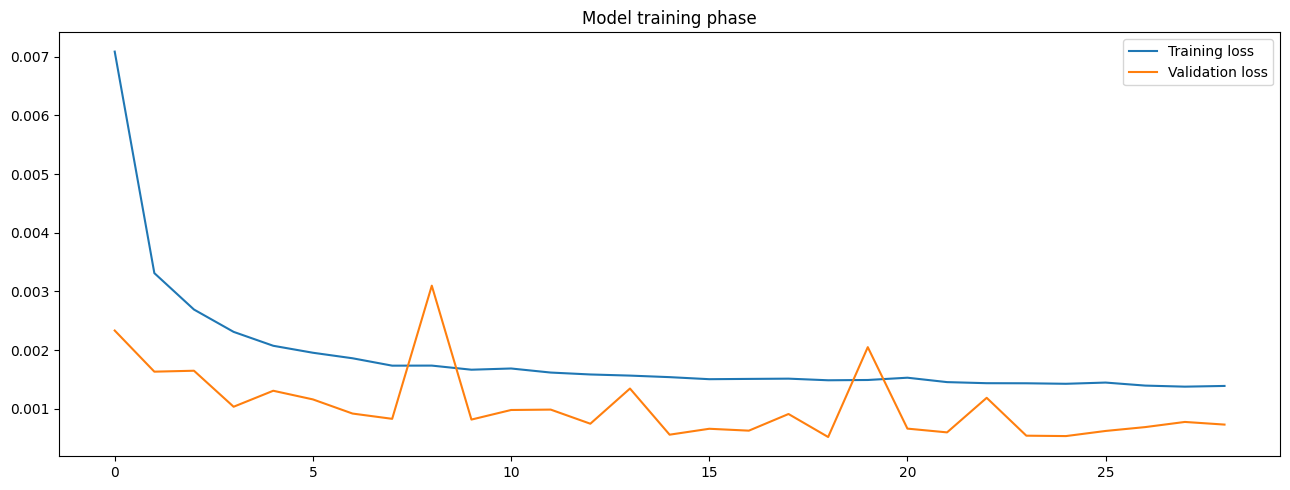

In [17]:
def plot_hist(hist):
    fig, ax = plt.subplots(figsize=(13,5))
    ax.plot(hist.history['loss'], label='Training loss')
    ax.plot(hist.history['val_loss'], label='Validation loss')
    ax.set_title('Model training phase')
    ax.legend()
    fig.tight_layout()
    plt.show()
plot_hist(history)

In [18]:
y_test_inv = scaler.inverse_transform(y_test_LSTM)
y_pred_inv = scaler.inverse_transform(y_pred_LSTM)

## LSTM performance

In [19]:
metrics = []
print("\n===== MULTI-HORIZON PERFORMANCE LSTM =====")
for h in range(horizon):
    true_vals = y_test_inv[:, h]
    pred_vals = y_pred_inv[:, h]
    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    mae = mean_absolute_error(true_vals, pred_vals)
    r2 = r2_score(true_vals,pred_vals)
    nse = 1 - (
        np.sum((true_vals - pred_vals) ** 2)
        / np.sum(
            (true_vals - np.mean(true_vals)) ** 2
        )
    )
    metrics.append([h + 1,rmse,mae,r2,nse])
# dataframe metrics
metrics_df = pd.DataFrame(
    metrics,
    columns=[
        "Horizon","RMSE","MAE","R2","NSE"
    ]
)
print(metrics_df)


===== MULTI-HORIZON PERFORMANCE LSTM =====
   Horizon       RMSE        MAE        R2       NSE
0        1   7.875201   6.084053  0.994295  0.994295
1        2  15.538004   8.843013  0.977778  0.977778
2        3  19.138009   9.997327  0.966269  0.966269
3        4  21.893019  11.431465  0.955835  0.955835
4        5  23.963575  12.927149  0.947057  0.947057
5        6  25.658140  14.350280  0.939274  0.939274
6        7  27.196121  15.505248  0.931745  0.931745


In [ ]:
test_index = df.index[-len(y_test_inv):]
# actual series
actual_series = pd.Series(
    y_test_inv[:, 0], index=test_index
)
forecast_df = pd.DataFrame(index=actual_series.index)
for h in range(horizon):
    temp_series = pd.Series(
        y_pred_inv[:, h], index=actual_series.index
    )
    forecast_df[f"t+{h+1}"] = temp_series

## Forecasted plots

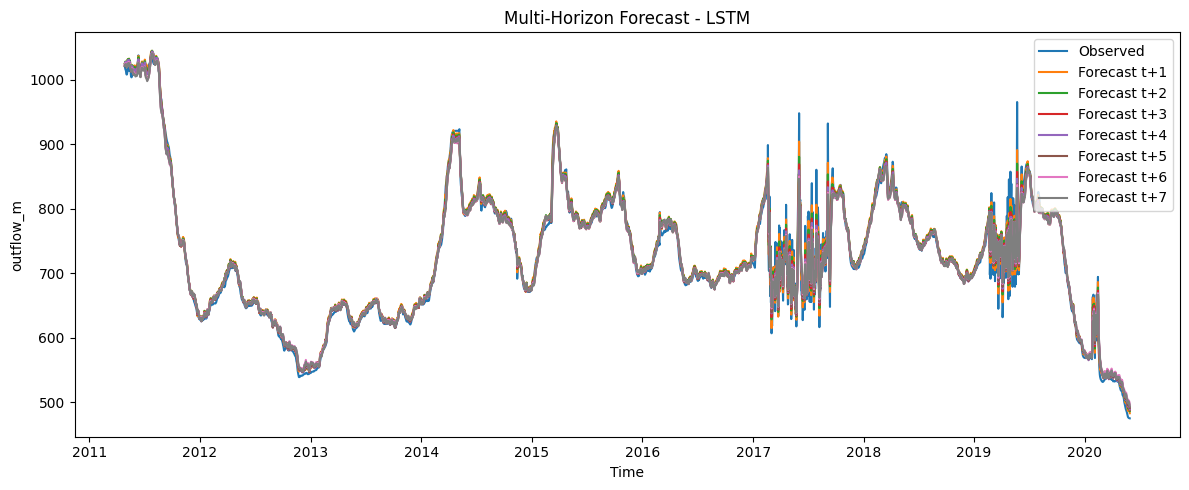

In [22]:
# fig = go.Figure()
# # Actual
# fig.add_trace(
#     go.Scatter(
#         x=actual_series.index,y=actual_series.values,mode="lines",name="Observed"
#     )
# )
# # Forecast horizons
# for h in range(horizon):
#     fig.add_trace(
#         go.Scatter(
#             x=forecast_df.index, y=forecast_df[f"t+{h+1}"],
#             mode="lines", name=f"Forecast t+{h+1}"
#         )
#     )
# fig.update_layout(
#     template="plotly_white",
#     title="Multi-Horizon Forecast - LSTM",
#     xaxis_title="Time",
#     yaxis_title=target,
#     width=1200,
#     height=500,
#     hovermode="x unified"
# )
# fig.show()

plt.figure(figsize=(12, 5))
# Actual series
plt.plot(actual_series.index, actual_series.values, label="Observed")
# Forecast horizons
for h in range(horizon):
    plt.plot(
        forecast_df.index, forecast_df[f"t+{h+1}"], label=f"Forecast t+{h+1}"
    )

plt.title("Multi-Horizon Forecast - LSTM")
plt.xlabel("Time")
plt.ylabel(target)
plt.legend()
plt.tight_layout()
plt.show()